In [1]:
import pandas as pd
import re
import os
import string
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Downloading NLTK resources
#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

### Loading Dataset

In [2]:
# Relative Path Configuration
BASE_DIR = os.getcwd()

# Define output directory
DATA_DIR = os.path.join(BASE_DIR, '..', 'Database', 'Cleaned_Datasets')
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
REVIEW_DATA_PATH = os.path.join(DATA_DIR, 'Merge_Review_Cleaned.csv')

# Load the cleaned review dataset
review_df = pd.read_csv(REVIEW_DATA_PATH)

### Inspecting Dataset

In [4]:
review_df.head()

,review_id,book_id,user_id,review_text,ratings,review_date,source,author,book_name
0,1,B0033UV8HI,A3HHXRELK8BHQG,Jace Rankin may be short but hes nothing to me...,3,2010-09-02,Amazon,Unknown,Unknown
1,2,B002HJV4DE,A2RGNZ0TRF578I,Great short read I didnt want to put it down s...,5,2013-10-08,Amazon,Unknown,Unknown
2,3,B002ZG96I4,A3S0H2HV6U1I7F,Ill start by saying this is the first of four ...,3,2014-04-11,Amazon,Unknown,Unknown
3,4,B002QHWOEU,AC4OQW3GZ919J,Aggie is Angela Lansbury who carries pocketboo...,3,2014-07-05,Amazon,Unknown,Unknown
4,5,B001A06VJ8,A3C9V987IQHOQD,I did not expect this type of book to be in li...,4,2012-12-31,Amazon,Unknown,Unknown


In [5]:
# Inspect structure and encoding
print(review_df.info())
print(review_df.sample(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77146 entries, 0 to 77145
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    77146 non-null  int64 
 1   book_id      77146 non-null  object
 2   user_id      77146 non-null  object
 3   review_text  77141 non-null  object
 4   ratings      77146 non-null  int64 
 5   review_date  77146 non-null  object
 6   source       77146 non-null  object
 7   author       77146 non-null  object
 8   book_name    77146 non-null  object
dtypes: int64(2), object(7)
memory usage: 5.3+ MB
None
       review_id  book_id  user_id  \
16983      16984  unknown  unknown   
12556      12557  unknown  unknown   
27709      27710  unknown  unknown   
32927      32928  unknown  unknown   
45482      45483  unknown  unknown   

                                             review_text  ratings review_date  \
16983  It is a dream of electrifying eroticism and in...        5  2025-01-0

In [6]:
# Initial sanity checks
print("Missing review_text:", review_df['review_text'].isnull().sum())

# Drop rows with missing review_text
review_df.dropna(subset=['review_text'], inplace=True)

print()
# review text length
print(review_df['review_text'].apply(lambda x: len(str(x).split())).describe())

Missing review_text: 5

count    77141.000000
mean       251.585370
std        319.989459
min          1.000000
25%         57.000000
50%        150.000000
75%        320.000000
max       3674.000000
Name: review_text, dtype: float64


In [7]:
# Initial sanity checks
print("Missing review_text:", review_df['review_text'].isnull().sum())

Missing review_text: 0


In [8]:
#2. Normalize and Clean Text

def clean_text(text):
    text = str(text).lower()  # Ensure text is string before processing
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r"\d+", "", text)  # Remove digits
    text = re.sub(r"[^\x00-\x7F]+", " ", text)  # Remove non-ASCII characters
    text = re.sub(rf"[{re.escape(string.punctuation)}]", "", text)  # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra whitespace
    return text


# Apply text cleaning
review_df['cleaned_text'] = review_df['review_text'].apply(clean_text)

# Remove very short reviews (e.g., less than 5 words)
review_df = review_df[review_df['cleaned_text'].apply(lambda x: len(x.split()) > 5)]

In [9]:
review_df.head()

,review_id,book_id,user_id,review_text,ratings,review_date,source,author,book_name,cleaned_text
0,1,B0033UV8HI,A3HHXRELK8BHQG,Jace Rankin may be short but hes nothing to me...,3,2010-09-02,Amazon,Unknown,Unknown,jace rankin may be short but hes nothing to me...
1,2,B002HJV4DE,A2RGNZ0TRF578I,Great short read I didnt want to put it down s...,5,2013-10-08,Amazon,Unknown,Unknown,great short read i didnt want to put it down s...
2,3,B002ZG96I4,A3S0H2HV6U1I7F,Ill start by saying this is the first of four ...,3,2014-04-11,Amazon,Unknown,Unknown,ill start by saying this is the first of four ...
3,4,B002QHWOEU,AC4OQW3GZ919J,Aggie is Angela Lansbury who carries pocketboo...,3,2014-07-05,Amazon,Unknown,Unknown,aggie is angela lansbury who carries pocketboo...
4,5,B001A06VJ8,A3C9V987IQHOQD,I did not expect this type of book to be in li...,4,2012-12-31,Amazon,Unknown,Unknown,i did not expect this type of book to be in li...


In [10]:
review_df.duplicated().sum()

0

In [11]:
print("Missing Values:\n" ,review_df.isnull().sum())

Missing Values:
 review_id       0
book_id         0
user_id         0
review_text     0
ratings         0
review_date     0
source          0
author          0
book_name       0
cleaned_text    0
dtype: int64


### Normalize , Clean Text and Remove Stopwords

In [ ]:
# Define custom stopwords (add common terms relevant to book reviews)
custom_stopwords = set([
    "book", "read", "reading", "author", "like", "love", "story", "novel", "pages", "characters","surprise","learn"
])

# Combine standard stopwords with custom stopwords
stop_words = set(stopwords.words('english')) | custom_stopwords

# Function to remove stopwords
def remove_stopwords(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and non-alphabetical words, lowercase(Case Normalization)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]
    
    return  ' '.join(filtered_tokens)

# Apply stopword removal to cleaned reviews
review_df['cleaned_tokens'] = review_df['cleaned_text'].apply(remove_stopwords)

# Display first few rows to verify
print(review_df[['cleaned_text', 'cleaned_tokens']].head())

### Stemming vs Lemmatization (Comparative Analysis)

In [13]:
# Initialize the Stemmer and Lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Sample subset of reviews for comparison
sample_reviews = review_df['cleaned_tokens'].sample(5).tolist()  # Random 5 reviews

In [14]:
# Function for Stemming
def apply_stemming(text):
    tokens = word_tokenize(text)
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens)

In [15]:
# Function for Lemmatization
def apply_lemmatization(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_tokens)


In [16]:
# Apply both Stemming and Lemmatization
sample_stemmed = [apply_stemming(review) for review in sample_reviews]
sample_lemmatized = [apply_lemmatization(review) for review in sample_reviews]

# Display comparison for review and output for both techniques
comparison_df = pd.DataFrame({
    'Original': sample_reviews,
    'Stemmed': sample_stemmed,
    'Lemmatized': sample_lemmatized
})

print(comparison_df)

                                            Original  \
0  twisting kaleidoscope turned adventure somethi...   
1  hey booktube channel youtube reviews video rev...   
2  worked international affairs journal first rel...   
3  reread july reread booktubeathon falling behin...   
4  one day panda stillwater shows yard addy micha...   

                                             Stemmed  \
0  twist kaleidoscop turn adventur someth much ex...   
1  hey booktub channel youtub review video review...   
2  work intern affair journal first releas rememb...   
3  reread juli reread booktubeathon fall behind o...   
4  one day panda stillwat show yard addi michael ...   

                                          Lemmatized  
0  twisting kaleidoscope turned adventure somethi...  
1  hey booktube channel youtube review video revi...  
2  worked international affair journal first rele...  
3  reread july reread booktubeathon falling behin...  
4  one day panda stillwater show yard addy michae..

### Tokenization and Word Frequency Analysis

In [17]:
# Lemmatization: Convert tokens to their base form
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

In [18]:
# Tokenize and Lemmatize
def tokenize_and_lemmatize(text):
    tokens = nltk.word_tokenize(text)  # Tokenize the text
    lemmatized_tokens = lemmatize_tokens(tokens)  # Lemmatize tokens
    return lemmatized_tokens

In [19]:
# Apply tokenization and lemmatization to the cleaned text
review_df['lemmatized_tokens'] = review_df['cleaned_text'].apply(tokenize_and_lemmatize)

# Flatten the list of lemmatized tokens to get the frequency of all words
all_lemmatized_tokens = [token for tokens in review_df['lemmatized_tokens'] for token in tokens]

# Generate frequency distribution
token_freq = Counter(all_lemmatized_tokens)

In [20]:
# Most common tokens
common_tokens = token_freq.most_common(20)
print("Most common tokens (lemmatized):", common_tokens)

Most common tokens (lemmatized): [('the', 949429), ('a', 621913), ('and', 582635), ('of', 501417), ('to', 487114), ('i', 346223), ('in', 300774), ('is', 289234), ('it', 286797), ('that', 239429), ('this', 203500), ('book', 168186), ('wa', 165363), ('for', 153096), ('with', 141930), ('but', 127269), ('he', 106471), ('her', 105505), ('you', 104647), ('not', 102622)]


In [21]:
# Plot histogram of the most common tokens
token_names, token_counts = zip(*common_tokens)

# Convert to DataFrame
token_df = pd.DataFrame({
    'Token': token_names,
    'Count': token_counts
})


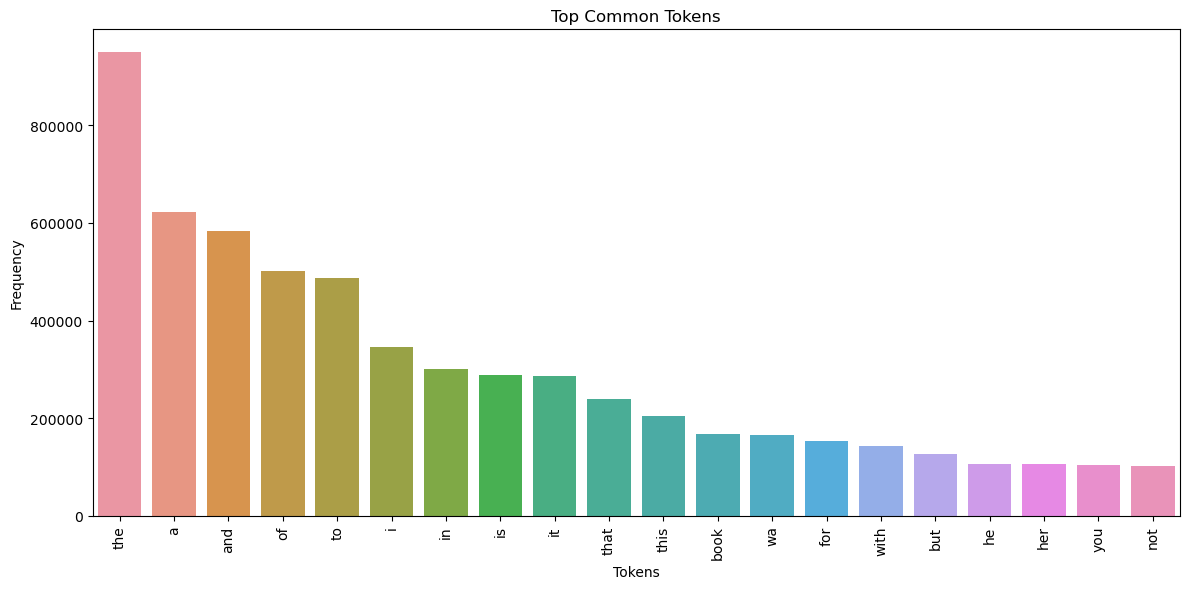

In [22]:
#plot

plt.figure(figsize=(12, 6))
sns.barplot(data=token_df, x='Token', y='Count')
plt.xticks(rotation=90)
plt.title('Top Common Tokens')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

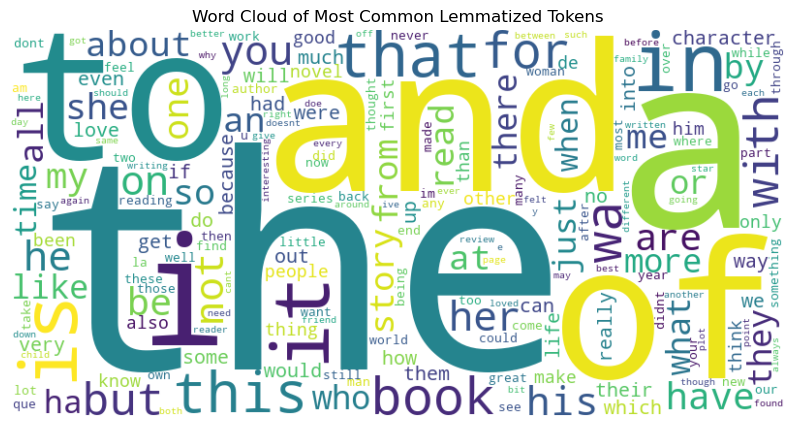

In [23]:
# Generate word cloud of the most common tokens
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(token_freq)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Common Lemmatized Tokens')
plt.show()

In [24]:
# Calculate vocabulary size after cleaning, filtering, and lemmatization
vocabulary_size = len(set(all_lemmatized_tokens))
print("Vocabulary Size (unique lemmatized tokens):", vocabulary_size)

Vocabulary Size (unique lemmatized tokens): 421367


### Save Cleaned Dataset

In [25]:
# Save cleaned dataset
output_path = os.path.join(DATA_DIR, "Review_Cleaned.csv")
review_df.to_csv(output_path, index=False, encoding='utf-8')

print(f"Cleaned review dataset saved at: {output_path}")


Cleaned review dataset saved at: C:\Users\HP\Desktop\Bookify\Notebooks\..\Database\Cleaned_Datasets\Review_Cleaned.csv


In [27]:
from nltk.tokenize import word_tokenize

# 1. Tokens before cleaning
raw_documents = review_df['review_text'].tolist()
all_tokens_before = [word_tokenize(doc) for doc in raw_documents]
total_tokens_before = sum(len(tokens) for tokens in all_tokens_before)

# 2. Tokens after cleaning (using Lemmatized column)
cleaned_documents = review_df['lemmatized_tokens'].tolist()
all_tokens_after = cleaned_documents  # No need to split since it's already a list of tokens
total_tokens_after = sum(len(tokens) for tokens in all_tokens_after)

# 3. Unique tokens after cleaning
unique_tokens = set(token for doc in all_tokens_after for token in doc)
unique_token_count = len(unique_tokens)

# 4. Average tokens per document
average_tokens = total_tokens_after / len(cleaned_documents)

# Output the results
print("Tokens before cleaning:", total_tokens_before)
print("Tokens after cleaning:", total_tokens_after)
print("Unique tokens after cleaning:", unique_token_count)
print("Average tokens per document:", average_tokens)


Tokens before cleaning: 19405344
Tokens after cleaning: 19316314
Unique tokens after cleaning: 421367
Average tokens per document: 257.86372798996115


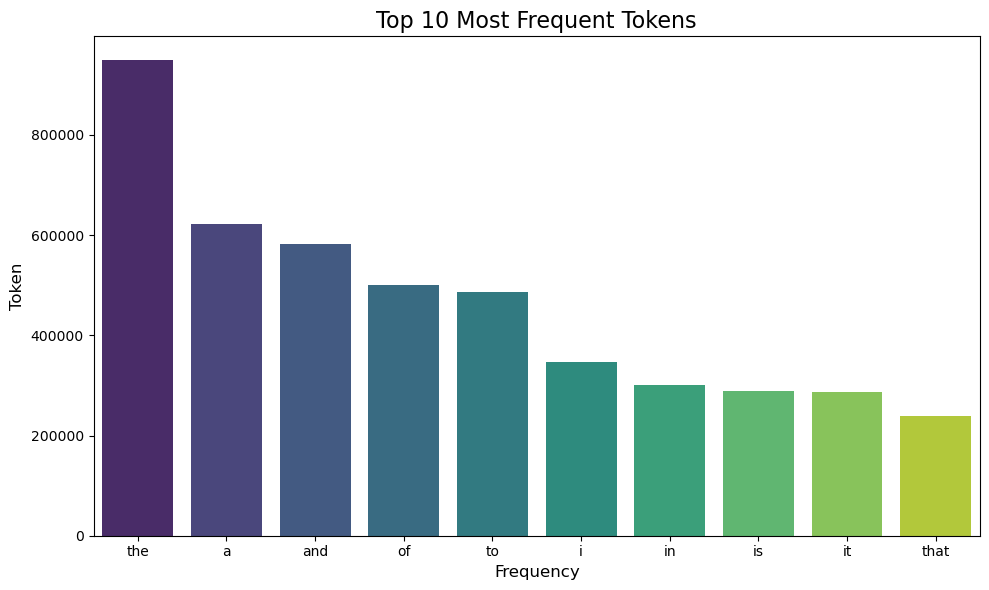

In [28]:
# Tokens and frequencies from your provided data
top_tokens = [('the', 949429), ('a', 621913), ('and', 582635), ('of', 501417),
              ('to', 487114), ('i', 346223), ('in', 300774), ('is', 289234),
              ('it', 286797), ('that', 239429)]

# Convert the list into a DataFrame
df_top_tokens = pd.DataFrame(top_tokens, columns=['Token', 'Frequency'])

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot( x='Token', y='Frequency', data=df_top_tokens, palette='viridis')

# Add titles and labels
plt.title('Top 10 Most Frequent Tokens', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Token', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()